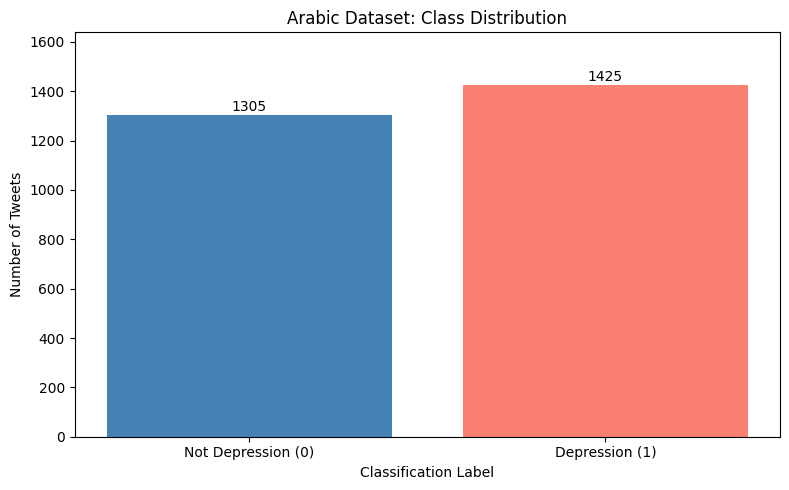

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

#Loads the cleaned Arabic dataset
df = pd.read_csv("arabic_clean_full.csv")

#Counts the number of tweets in each class
counts = df["label"].value_counts().reindex([0, 1], fill_value=0)

#Creates the bar chart
plt.figure(figsize=(8, 5))

bars = plt.bar(
    ["Not Depression (0)", "Depression (1)"],
    counts.values,
    color=["steelblue", "salmon"]
)

#Adding labels and a title
plt.title("Arabic Dataset: Class Distribution")
plt.xlabel("Classification Label")
plt.ylabel("Number of Tweets")

#Displays numbers above each bar
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 15,
        int(bar.get_height()),
        ha="center"
    )

plt.ylim(0, max(counts.values) * 1.15)
plt.tight_layout()
plt.show()


**Figure 1: Arabic Dataset Class Distribution**

Figure 1 shows the distribution of classification labels in the cleaned Arabic dataset. Of the 2,730 tweets, 1,425 (52.2%) are labelled as depression, while 1,305 (47.8%) are labelled as not depression. The distribution is relatively balanced, with only a slight majority of depression-labelled tweets. Overall, the graph shows a relatively even distribution between the two categories, with depression-labelled tweets slightly outnumbering non-depression-labelled tweets.

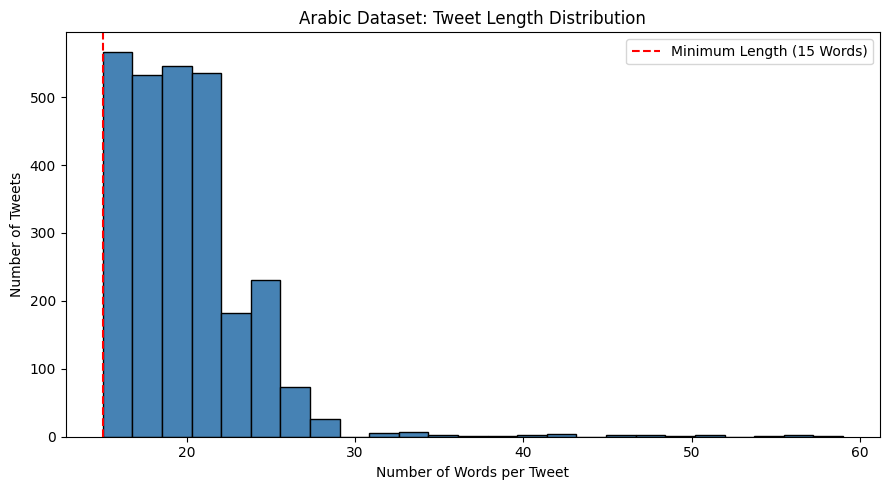

Tweet Length Statistics:
count    2730.000000
mean       19.869597
std         4.126152
min        15.000000
25%        17.000000
50%        19.000000
75%        22.000000
max        59.000000
Name: n_words, dtype: float64


In [2]:

#Visualization 2: Arabic Tweet Length Distribution

#Creates the histogram
plt.figure(figsize=(9, 5))

plt.hist(
    df["n_words"],
    bins=25,
    color="steelblue",
    edgecolor="black"
)

#Shows the minimum word requirement
plt.axvline(
    x=15,
    color="red",
    linestyle="--",
    label="Minimum Length (15 Words)"
)

#Adding labels and a title
plt.title("Arabic Dataset: Tweet Length Distribution")
plt.xlabel("Number of Words per Tweet")
plt.ylabel("Number of Tweets")

plt.legend()
plt.tight_layout()
plt.show()

#Displays a summary of the statistics
print("Tweet Length Statistics:")
print(df["n_words"].describe())


**Figure 2: Arabic Tweet Length Distribution**

Figure 2 shows the distribution of tweet lengths in the cleaned Arabic dataset. All 2,730 tweets contain at least 15 words, with an average length of approximately 19.9 words and a median of 19 words. The longest tweet contains 59 words. The distribution indicates that most tweets are relatively short, despite meeting the minimum length requirement. The minimum length requirement was applied to ensure that each post contained enough text to be divided into three meaningful sections for the project's text splitting tasks.

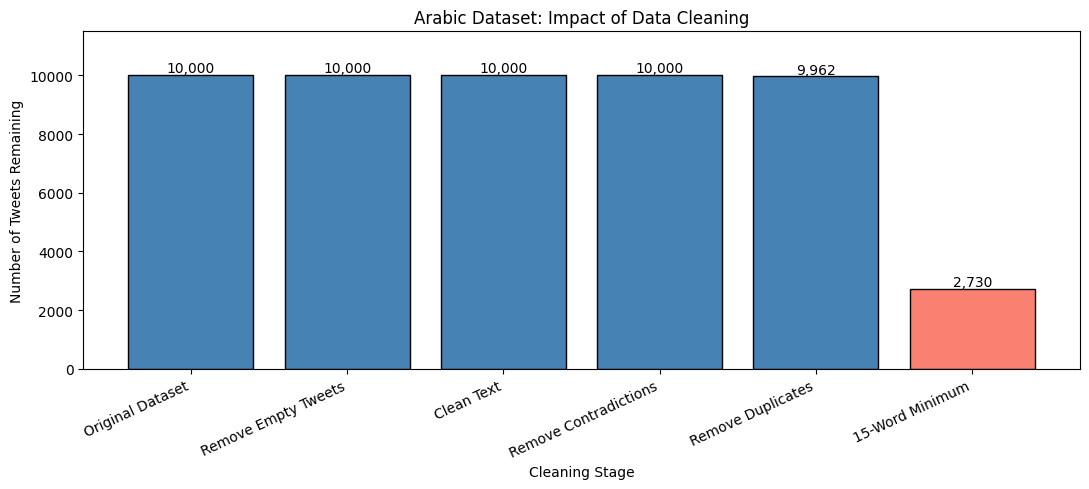

In [3]:

#Visualization 3: Impact of Data Cleaning

#Cleaning statistics from the Arabic README
cleaning_steps = [
    "Original Dataset",
    "Remove Empty Tweets",
    "Clean Text",
    "Remove Contradictions",
    "Remove Duplicates",
    "15-Word Minimum"
]

tweets_remaining = [10000, 10000, 10000, 10000, 9962, 2730]

#Creates the bar chart
plt.figure(figsize=(11, 5))

bars = plt.bar(
    cleaning_steps,
    tweets_remaining,
    color=["steelblue"] * 5 + ["salmon"],
    edgecolor="black"
)

#Adding labels and a title
plt.title("Arabic Dataset: Impact of Data Cleaning")
plt.xlabel("Cleaning Stage")
plt.ylabel("Number of Tweets Remaining")

#Displays numbers above each bar
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 100,
        f"{int(bar.get_height()):,}",
        ha="center"
    )

plt.xticks(rotation=25, ha="right")
plt.ylim(0, 11500)

plt.tight_layout()
plt.show()


**Figure 3: Impact of Data Cleaning on the Arabic Dataset**

Figure 3 illustrates how the number of Arabic tweets changed throughout the data cleaning process. The original dataset contained 10,000 tweets, which decreased slightly to 9,962 after removing duplicates. The largest reduction occurred when applying the minimum length requirement of 15 words, leaving 2,730 tweets. Overall, approximately 72.7% of the original dataset was removed during preprocessing. This reduction shows that a large portion of the original tweets did not meet the length requirement needed for the project's text splitting tasks.

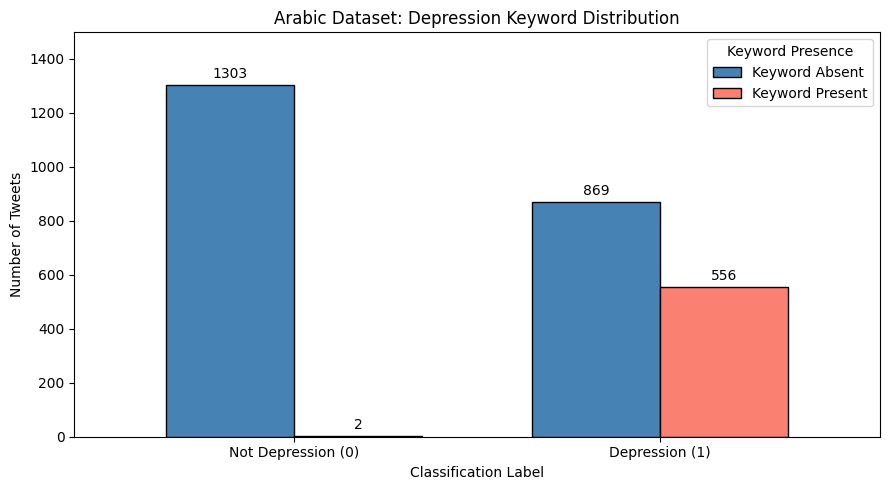

Keyword Distribution:
                    Keyword Absent  Keyword Present
Not Depression (0)            1303                2
Depression (1)                 869              556

Keyword Distribution (%):
                    Keyword Absent  Keyword Present
Not Depression (0)            99.8              0.2
Depression (1)                61.0             39.0


In [5]:

#Visualization 4: Depression Keyword Distribution by Label

#Count keyword presence for each classification label
keyword_counts = pd.crosstab(
    df["label"],
    df["has_keyword"]
)

#Both True and False categories are included
keyword_counts = keyword_counts.reindex(
    index=[0, 1],
    columns=[False, True],
    fill_value=0
)

#Renames labels
keyword_counts.index = [
    "Not Depression (0)",
    "Depression (1)"
]

keyword_counts.columns = [
    "Keyword Absent",
    "Keyword Present"
]

#Creates the grouped bar chart
ax = keyword_counts.plot(
    kind="bar",
    figsize=(9, 5),
    color=["steelblue", "salmon"],
    edgecolor="black",
    width=0.7
)

#Adding labels and a title
plt.title("Arabic Dataset: Depression Keyword Distribution")
plt.xlabel("Classification Label")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=0)
plt.legend(title="Keyword Presence")

#Displays numbers above each bar
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.ylim(0, keyword_counts.values.max() * 1.15)
plt.tight_layout()
plt.show()

#Displays a summary of the statistics
print("Keyword Distribution:")
print(keyword_counts)

#Displays percentages within each classification label
print("\nKeyword Distribution (%):")
print(keyword_counts.div(
    keyword_counts.sum(axis=1), axis=0
).mul(100).round(1))


**Figure 4: Arabic Depression Keyword Distribution by Label**

Figure 4 compares the presence of the Arabic depression keyword (اكتئاب) across the two classification labels. The keyword appears in 556 depression-labelled tweets (39.0%), compared to only 2 non-depression-labelled tweets (0.2%). This shows that the keyword is strongly associated with depression-labelled tweets in the cleaned dataset, although most tweets in this category do not contain the keyword.